In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
from tabulate import tabulate
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from google.colab import drive

In [2]:
# Загрузка файла данных в формате 'csv':
from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv('/content/drive/MyDrive/Innopolis_II/athlete_events.csv', sep=',')
df=data


Mounted at /content/drive


In [3]:
#Строки и столбцы
rows_num, columns_num = df.shape
print(f'Общее количество строк: {rows_num}\nОбщее количество столбцов: {columns_num}')

def columnValues(df):
    row = [df.nunique(), (df == 0).sum(axis=0), df.isna().sum(), round(df.isna().sum() / len(df) * 100, 1), df.dtypes]
    return row

data = []
for column in df:
    data.append([column] + columnValues(df[column]))

print(tabulate(data, headers=['название', 'к-во уник знач', 'к-во 0-ых знач', 'пустые','% пустых', 'тип данн'], tablefmt='orgtbl'))

num_rows = len(df)
num_columns = len(df.columns)
print("Количество строк:", num_rows)
print("Количество столбцов:", num_columns)
print("----------------------------------------------")
# Размер DataFrame в оперативной памяти
memory_usage = df.memory_usage().sum()
print("Размер DataFrame в памяти:", memory_usage, "байт")
print("----------------------------------------------")
# Анализ интервальных переменных
numerical_columns = df.select_dtypes(include=[int, float]).columns
for column in numerical_columns:
    print("Статистика для столбца", column)
    print("Доля пропусков", df[column].isna().sum() / num_rows)
    print ("Стандартное отклонение", df[column].std())
    print("Минимальное значение:", df[column].min())
    print("Медиана:", df[column].median())
    print("Среднее значение:", df[column].mean())
    print("Максимальное значение:", df[column].max())
    print("10-й персентиль:", df[column].quantile(0.1))
    print("25-й персентиль:", df[column].quantile(0.25))
    print("75-й персентиль:", df[column].quantile(0.75))
    print("90-й персентиль:", df[column].quantile(0.9))
    print("Дисперсия:", df[column].var())
    print("----------------------------------------------")

# Анализ категориальных переменных
categorical_columns = df.select_dtypes(include=[object]).columns
for column in categorical_columns:
    print("Статистика для столбца", column)
    print("Доля пропусков", df[column].isna().sum() / num_rows)
    mode = df[column].mode()[0]
    mode_count = df[column].value_counts()[mode]
    unique_values = df[column].nunique()
    print("Мода:", mode)
    print("Количество встреч моды:", mode_count)
    print("Уникальные значения:", unique_values)
    print("----------------------------------------------")

Общее количество строк: 271116
Общее количество столбцов: 15
| название   |   к-во уник знач |   к-во 0-ых знач |   пустые |   % пустых | тип данн   |
|------------+------------------+------------------+----------+------------+------------|
| ID         |           135571 |                0 |        0 |        0   | int64      |
| Name       |           134732 |                0 |        0 |        0   | object     |
| Sex        |                2 |                0 |        0 |        0   | object     |
| Age        |               74 |                0 |     9474 |        3.5 | float64    |
| Height     |               95 |                0 |    60171 |       22.2 | float64    |
| Weight     |              220 |                0 |    62875 |       23.2 | float64    |
| Team       |             1184 |                0 |        0 |        0   | object     |
| NOC        |              230 |                0 |        0 |        0   | object     |
| Games      |               51 |      

In [4]:
#Замена пропусков в столбцах на среднее значение
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Height'] = df['Height'].fillna(df['Height'].mean())
df['Weight'] = df['Weight'].fillna(df['Weight'].mean())

Text(0.5, 1.0, 'Связь роста и веса')

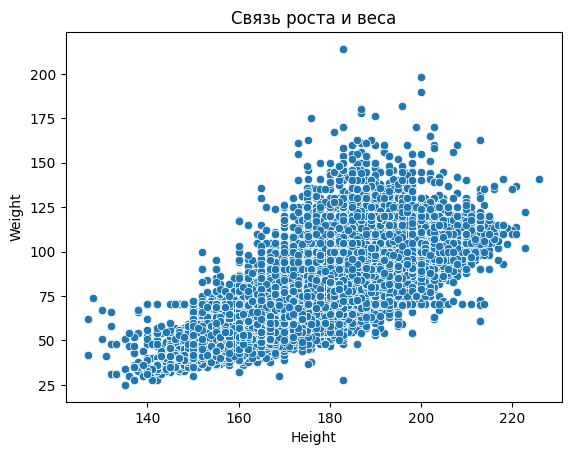

In [5]:
import matplotlib
import matplotlib.pyplot as plt
sns.scatterplot(x="Height", y="Weight", data=df)
plt.title("Связь роста и веса")

Видим линейную зависимость роста и веса.

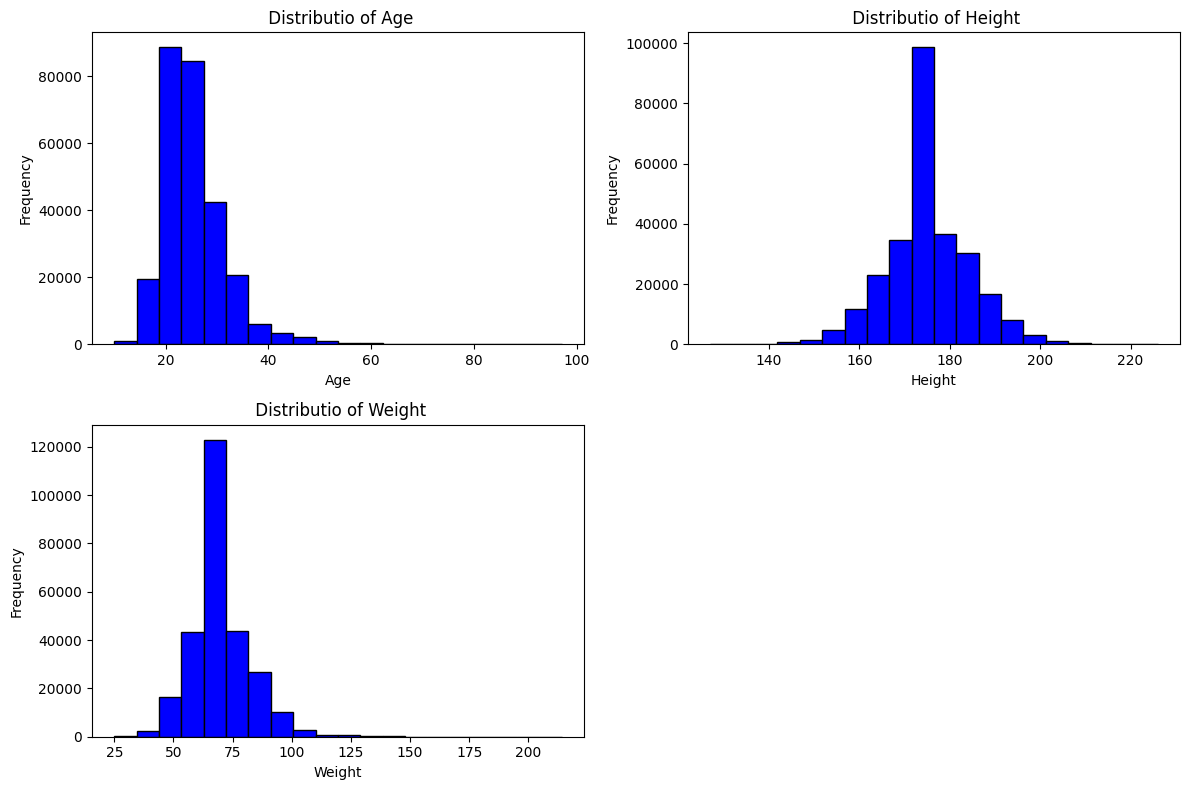

In [6]:
num_columns = ['Age', 'Height', 'Weight']
plt.figure(figsize = (12,8))
for i, col in enumerate(num_columns, 1):
    plt.subplot(2, 2, i)
    plt.hist(df[col], bins=20, color='blue', edgecolor='black')
    plt.title(f' Distributio of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

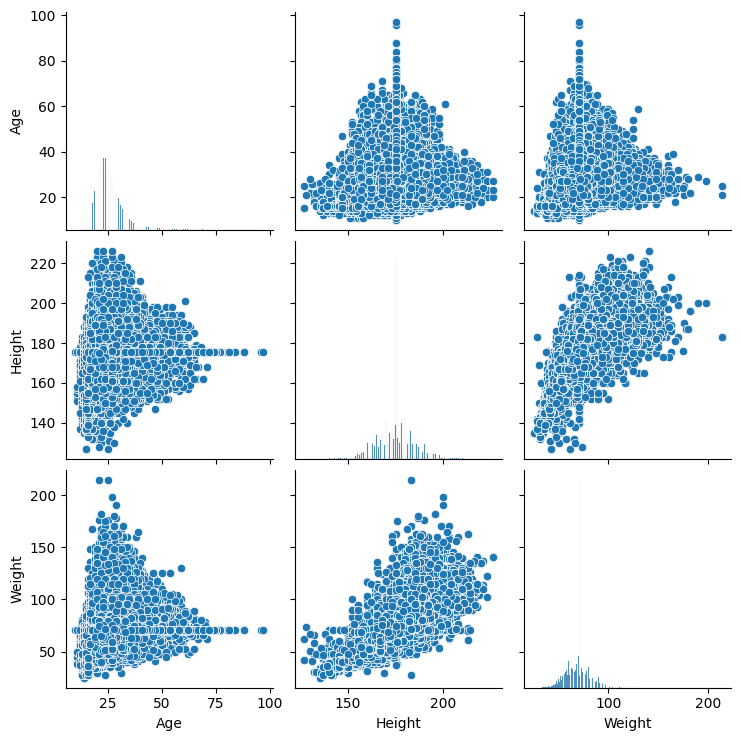

In [7]:
sns.pairplot(df[num_columns])
plt.show()

In [8]:
#график плотности распределения, график box-plot для обнаружения выбросов в значениях
fig_dist = px.histogram(df, x = 'Age', title = 'Age')
box_dist = px.box(df, x = 'Age', title = 'box-plot Age')
fig_dist.show()
box_dist.show()
first_quartile, third_quartile = np.quantile(df['Age'], 0.25), np.quantile(df['Age'], 0.75)
iqr = (third_quartile - first_quartile) * 1.5
range_box = [first_quartile - iqr, third_quartile + iqr]
print('Межквартильный рахмах: ', iqr)
print('Первый квартиль:', first_quartile,'\nВторой квартиль: ', third_quartile)
print('Границы допустимых значений: ', range_box)

Output hidden; open in https://colab.research.google.com to view.

In [10]:
#график плотности распределения, график box-plot для обнаружения выбросов в значениях
fig_dist = px.histogram(df, x = 'Height', title = 'Height')
box_dist = px.box(df, x = 'Height', title = 'box-plot Height')
fig_dist.show()
box_dist.show()
first_quartile, third_quartile = np.quantile(df['Height'], 0.25), np.quantile(df['Height'], 0.75)
iqr = (third_quartile - first_quartile) * 1.5
range_box = [first_quartile - iqr, third_quartile + iqr]
print('Межквартильный рахмах: ', iqr)
print('Первый квартиль:', first_quartile,'\nВторой квартиль: ', third_quartile)
print('Границы допустимых значений: ', range_box)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from scipy.stats import shapiro
from scipy.stats import mannwhitneyu
from scipy.stats import tukey_hsd
import random as r

#Удаление выбросов из столбца Age
for _ in df['Age']:
  if (_ > third_quartile + iqr) or (_ < first_quartile - iqr):
    df.drop(df.loc[df['Age'] == _].index, inplace=True)#

#Проверка нормальности распределения
#H0 - значения возраста в датасете вероятно распределены нормально, H1 - отвергаем нулевую гипотезу о нормальности распределения, альфа уровень p-value: 0.05
shapiro_test = shapiro(df['Age'])
a_level = 0.05
print(shapiro_test)
if shapiro_test.pvalue < a_level:
  print('Отклоняем H0 - не можем утверждать о нормальном распределении')
else:
  print('Нет оснований для отклонения H0 о нормальном распределении')


ShapiroResult(statistic=0.9861673680251943, pvalue=2.0883648068486156e-79)
Отклоняем H0 - не можем утверждать о нормальном распределении


/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 259135.



In [13]:
from scipy import stats
male = df[df['Sex'] == 'M']['Height']
female = df[df['Sex'] == 'F']['Height']

results = stats.ttest_ind(female, male)

print(results.pvalue)

0.0


In [14]:
df

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.00000,80.000000,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.00000,60.000000,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,175.33897,70.702393,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,175.33897,70.702393,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.00000,82.000000,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.00000,89.000000,Poland-1,POL,1976 Winter,1976,Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,M,27.0,176.00000,59.000000,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,M,27.0,176.00000,59.000000,Poland,POL,2014 Winter,2014,Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.00000,96.000000,Poland,POL,1998 Winter,1998,Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN


In [15]:
# Удаляем ненужные столбцы
df = df.drop(columns=['Name', 'Team', 'NOC', 'Games', 'Year', 'City', 'Event', 'Medal'])


In [16]:
# Список категориальных столбцов
categorical_columns = df.select_dtypes(include=[object, 'category']).columns

# Проверяем, есть ли такие столбцы
if len(categorical_columns) == 0:
    print("Категориальные данные отсутствуют")
else:
    for col in categorical_columns:
        mode = df[col].mode()[0]
        mode_count = df[col].value_counts()[mode]
        print(f'Для переменной {col} мода: {mode}, количество: {mode_count}')

Для переменной Sex мода: M, количество: 196594
Для переменной Season мода: Summer, количество: 222552
Для переменной Sport мода: Athletics, количество: 38624


In [17]:
# Кодировка категориальных переменных с использованием OneHotEncoding
df = pd.get_dummies(df, columns=categorical_columns)
print(f'Категориальные переменные: {len(categorical_columns)}')

Категориальные переменные: 3


In [18]:
# Определение признаков и целевой переменной
X = df.drop('Height', axis=1)
y = df['Height']

# Разделяем данные на тренировочную и тестовую выборки
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучение моделей

In [21]:
# Метод kNN
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

# Линейная регрессия
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Дерево решений
from sklearn.tree import DecisionTreeRegressor
tree = DecisionTreeRegressor(random_state=42)
tree.fit(X_train, y_train)

# Случайный лес
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Градиентный бустинг
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

# Оценка качества моделей на тестовых данных

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Предсказания на тестовых данных
y_pred_knn = knn.predict(X_test)
y_pred_lr = lr.predict(X_test)
y_pred_tree = tree.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)

Вычисление метрики для моделей

In [23]:
# Метрики для K-ближайших соседей (KNN)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

# Метрики для линейной регрессии
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Метрики для дерева решений
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

# Метрики для случайного леса
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Метрики для градиентного бустинга
mae_gb = mean_absolute_error(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

In [25]:
# Вывод результатов
print(f"K-ближайших соседей (KNN):\nMAE: {mae_knn}:\nMSE: {mse_knn}\nR²: {r2_knn}\n")
print(f"Линейная регрессия:\nMAE: {mae_lr}\nMSE: {mse_lr}\nR²: {r2_lr}\n")
print(f"Дерево решений:\nMAE: {mae_tree}\nMSE: {mse_tree}\nR²: {r2_tree}\n")
print(f"Случайный лес:\nMAE: {mae_rf}\nMSE: {mse_rf}\nR²: {r2_rf}\n")
print(f"Градиентный бустинг:\nMAE: {mae_gb}\nMSE: {mse_gb}\nR²: {r2_gb}")

K-ближайших соседей (KNN):
MAE: 3.344875668178159:
MSE: 25.635755816335354
R²: 0.7026618925935453

Линейная регрессия:
MAE: 3.697959134756907
MSE: 24.37926204230373
R²: 0.717235423540524

Дерево решений:
MAE: 2.071456214741567
MSE: 19.075735027297725
R²: 0.778748752678105

Случайный лес:
MAE: 2.0099276307243947
MSE: 12.068801683590669
R²: 0.8600191592956254

Градиентный бустинг:
MAE: 3.3083148336384953
MSE: 21.154457221130425
R²: 0.7546385478779735


Поиск минимального значения MAE, MSE и максимального значения R²

In [27]:
# Список метрик для всех моделей
metrics = {
    "KNN": (mae_knn, mse_knn, r2_knn),
    "Линейная регрессия": (mae_lr, mse_lr, r2_lr),
    "Дерево решений": (mae_tree, mse_tree, r2_tree),
    "Случайный лес": (mae_rf, mse_rf, r2_rf),
    "Градиентный бустинг": (mae_gb, mse_gb, r2_gb)
}


# Находим минимальные значения MAE и MSE, и максимальное значение R²
min_mae = min(mae_knn, mae_lr, mae_tree, mae_rf, mae_gb)
min_mse = min(mse_knn, mse_lr, mse_tree, mse_rf, mse_gb)
max_r2 = max(r2_knn, r2_lr, r2_tree, r2_rf, r2_gb)

print(min_mae)
print(min_mse)
print(max_r2)

# Поиск модели, которая соответствует всем этим значениям
best_models = [
    model for model, (mae, mse, r2) in metrics.items()
    if mae == min_mae and mse == min_mse and r2 == max_r2
]
print('-----------------------------------------------------------------------')
# Вывод результа
if len(best_models) > 1:
    print(f"Лучшие модели по MAE, MSE и R²:\n{','.join(best_models)}")
else:
    print(f"Лучшая модель по MAE, MSE и R²: {best_models[0]}")

2.0099276307243947
12.068801683590669
0.8600191592956254
-----------------------------------------------------------------------
Лучшая модель по MAE, MSE и R²: Случайный лес
